<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/Fraud_detection_22_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
df=pd.read_excel('/content/Fraud_Detection_Dataset.xlsx',sheet_name=2)
df.head()

,Transaction_ID,Transaction_Date,Transaction_Time,Customer_ID,Customer_Name,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Merchant_Category,Merchant_Name,...,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,Is_Weekend,Is_Night_Transaction,Previous_Fraud_Flag,Is_Fraud
0,TXN200000,2025-01-15,06:48:02,CUST100030,Aditya Patel,41,2,199.98,Home Improvement,HomeFix,...,54.2,21.5,15.50,2,273.49,0.273,0,0,0,0
1,TXN200001,2025-04-06,11:04:13,CUST101156,Rohan Kumar,42,11,66.32,Clothing,FashionPoint,...,37.3,23.7,5.42,2,95.22,0.168,1,0,0,0
2,TXN200002,2025-01-21,13:21:11,CUST100068,Ava Sharma,38,1,91.12,Digital Goods,DigiMedia,...,39.7,8.5,3.03,1,40.02,0.586,0,0,0,0
3,TXN200003,2025-11-15,19:07:56,CUST100165,Wei Sharma,43,37,54.56,Entertainment,StreamPlus,...,35.1,4.5,26.32,0,42.80,0.101,1,0,0,0
4,TXN200004,2025-04-09,10:35:46,CUST100063,James Singh,42,43,516.69,Money Transfer,SendFast,...,32.9,9.1,16.08,1,247.95,0.268,0,0,0,0


##Problem Statement - To Identify Whether the transaction is Fraduelent or not?


STEPS PERFORMED BRIEF OVERVIEW

Data Loading and Initial Inspection: We
started by loading the Fraud detection dataset file into a pandas DataFrame and performing initial checks.
Data Cleaning:
Label Encoding: Categorical features  converted into numerical representations (0s and 1s) for model compatibility.
EDA - Data Exploration and Visualization: We explored the dataset's descriptive statistics
Outliers Detection - visualized the distributions of numerical columns using box plots.
Multicollinearity - A correlation matrix was also generated to understand relationships between features.
Hypothesis Testing: We conducted several hypothesis tests to investigate specific relationships.
Machine Learning Model (Logistic Regression): defined the target variable (. We then split the data into training and testing sets. A Logistic Regression model was iteratively built using statsmodels, starting with all significant features and then progressively removing features with high p-values.
Model Diagnostics: The final Logistic Regression model was evaluated using: A Confusion Matrix and An ROC Curve and AUC Score.



In [64]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4995,False
4996,False
4997,False
4998,False


In [65]:
df.isnull().sum()

,0
Transaction_ID,0
Transaction_Date,0
Transaction_Time,0
Customer_ID,0
Customer_Name,0
Customer_Age,0
Account_Tenure_Months,0
Transaction_Amount_USD,0
Merchant_Category,0
Merchant_Name,0


Removing Unnecessary columns

In [66]:
df= df.drop(columns=['Transaction_ID','Transaction_Date','Transaction_Time','Customer_ID','Customer_Name','Merchant_Category','Merchant_Name','Transaction_City','Transaction_Country','Home_City','Home_Country',])

In [67]:
df.head()

,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Transaction_Type,Device_Type,Card_Present,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,Is_Weekend,Is_Night_Transaction,Previous_Fraud_Flag,Is_Fraud
0,41,2,199.98,ATM Withdrawal,Web Browser,Yes,54.2,21.5,15.50,2,273.49,0.273,0,0,0,0
1,42,11,66.32,ATM Withdrawal,Web Browser,No,37.3,23.7,5.42,2,95.22,0.168,1,0,0,0
2,38,1,91.12,Online,Mobile App,Yes,39.7,8.5,3.03,1,40.02,0.586,0,0,0,0
3,43,37,54.56,Online,Mobile App,Yes,35.1,4.5,26.32,0,42.80,0.101,1,0,0,0
4,42,43,516.69,Online,ATM,No,32.9,9.1,16.08,1,247.95,0.268,0,0,0,0


All the unnessary columns are removed

In [68]:
df.shape

(5000, 16)

We are checking whether to use one hot encoding or label encoding

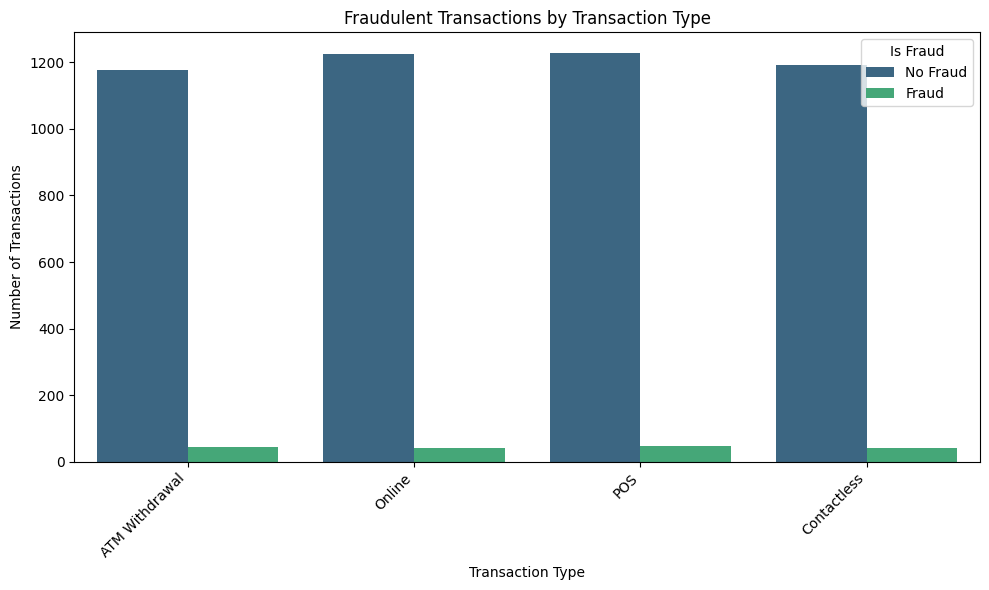

In [69]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Transaction_Type', hue='Is_Fraud', palette='viridis')
plt.title('Fraudulent Transactions by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Is Fraud', labels=['No Fraud', 'Fraud'])
plt.tight_layout()
plt.show()

Because in all atm withdrawal whatever type of transaction the number of transaction is same. you need one hot encoding where is there is difference in the number of transaction .

### Encoding Categorical Features

In [70]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for 'Transaction_Type'
le = LabelEncoder()
df['Transaction_Type_Encoded'] = le.fit_transform(df['Transaction_Type'])
df = df.drop(columns=['Transaction_Type'])

print("Transaction_Type mapping:")
for i, item in enumerate(le.classes_):
    print(f"{item}: {i}")

Transaction_Type mapping:
ATM Withdrawal: 0
Contactless: 1
Online: 2
POS: 3


In [71]:
# One-Hot Encoding for 'Device_Type'
df = pd.get_dummies(df, columns=['Device_Type'], prefix='Device', dtype=int)
df.head()

,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Card_Present,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,Is_Weekend,Is_Night_Transaction,Previous_Fraud_Flag,Is_Fraud,Transaction_Type_Encoded,Device_ATM,Device_Mobile App,Device_POS Terminal,Device_Web Browser
0,41,2,199.98,Yes,54.2,21.5,15.50,2,273.49,0.273,0,0,0,0,0,0,0,0,1
1,42,11,66.32,No,37.3,23.7,5.42,2,95.22,0.168,1,0,0,0,0,0,0,0,1
2,38,1,91.12,Yes,39.7,8.5,3.03,1,40.02,0.586,0,0,0,0,2,0,1,0,0
3,43,37,54.56,Yes,35.1,4.5,26.32,0,42.80,0.101,1,0,0,0,2,0,1,0,0
4,42,43,516.69,No,32.9,9.1,16.08,1,247.95,0.268,0,0,0,0,2,1,0,0,0


### Converting Boolean Device Type Columns to Integers

In [72]:
# Convert existing boolean 'Device_' columns to integer (0/1)
for col in df.columns:
    if col.startswith('Device_') and df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

df.head()

,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Card_Present,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,Is_Weekend,Is_Night_Transaction,Previous_Fraud_Flag,Is_Fraud,Transaction_Type_Encoded,Device_ATM,Device_Mobile App,Device_POS Terminal,Device_Web Browser
0,41,2,199.98,Yes,54.2,21.5,15.50,2,273.49,0.273,0,0,0,0,0,0,0,0,1
1,42,11,66.32,No,37.3,23.7,5.42,2,95.22,0.168,1,0,0,0,0,0,0,0,1
2,38,1,91.12,Yes,39.7,8.5,3.03,1,40.02,0.586,0,0,0,0,2,0,1,0,0
3,43,37,54.56,Yes,35.1,4.5,26.32,0,42.80,0.101,1,0,0,0,2,0,1,0,0
4,42,43,516.69,No,32.9,9.1,16.08,1,247.95,0.268,0,0,0,0,2,1,0,0,0


### Encoding `Card_Present`

In [73]:
# Label Encoding for 'Card_Present'
df['Card_Present_Encoded'] = df['Card_Present'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['Card_Present'])
df.head()

,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,Is_Weekend,Is_Night_Transaction,Previous_Fraud_Flag,Is_Fraud,Transaction_Type_Encoded,Device_ATM,Device_Mobile App,Device_POS Terminal,Device_Web Browser,Card_Present_Encoded
0,41,2,199.98,54.2,21.5,15.50,2,273.49,0.273,0,0,0,0,0,0,0,0,1,1
1,42,11,66.32,37.3,23.7,5.42,2,95.22,0.168,1,0,0,0,0,0,0,0,1,0
2,38,1,91.12,39.7,8.5,3.03,1,40.02,0.586,0,0,0,0,2,0,1,0,0,1
3,43,37,54.56,35.1,4.5,26.32,0,42.80,0.101,1,0,0,0,2,0,1,0,0,1
4,42,43,516.69,32.9,9.1,16.08,1,247.95,0.268,0,0,0,0,2,1,0,0,0,0


In [74]:
df.shape

(5000, 19)

In [77]:
df['Is_Fraud'].value_counts()

,count
Is_Fraud,
0,4825
1,175


checking imbalance of data again

### Handling Class Imbalance with SMOTE

Given the significant class imbalance observed in the `Is_Fraud` column (4825 non-fraudulent vs. 175 fraudulent transactions), we will use **SMOTE (Synthetic Minority Oversampling Technique)** to balance the dataset. SMOTE works by creating synthetic samples for the minority class, which helps in improving the performance of machine learning models on imbalanced datasets.

In [78]:
# Import SMOTE
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = df.drop('Is_Fraud', axis=1)
y = df['Is_Fraud']

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Shape of X before SMOTE:", X.shape)
print("Shape of y before SMOTE:", y.shape)
print("Shape of X after SMOTE:", X_resampled.shape)
print("Shape of y after SMOTE:", y_resampled.shape)

print("\nClass distribution of 'Is_Fraud' after SMOTE:")
display(y_resampled.value_counts())

Shape of X before SMOTE: (5000, 18)
Shape of y before SMOTE: (5000,)
Shape of X after SMOTE: (9650, 18)
Shape of y after SMOTE: (9650,)

Class distribution of 'Is_Fraud' after SMOTE:


,count
Is_Fraud,
0,4825
1,4825


### Feature Scaling

To ensure that all numerical features contribute equally to the model training and to prevent features with larger values from dominating, we will apply **Standard Scaling** to the `X_resampled` dataset. Standard scaling transforms the data such that it has a mean of 0 and a standard deviation of 1. This is a crucial preprocessing step for many machine learning algorithms, especially those that are distance-based or rely on gradient descent.

In [79]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns from the original DataFrame before dropping 'Is_Fraud'
# We need to exclude the encoded categorical columns and 'Is_Fraud' itself
numerical_cols_to_scale = df.select_dtypes(include=['number']).columns.tolist()
numerical_cols_to_scale.remove('Is_Fraud') # Remove target variable

# Exclude previously encoded 'Device_' and 'Card_Present_Encoded' from scaling if they are already 0/1
# This assumes these are already in their final integer representation
# If any of these were still considered 'numbers' by select_dtypes, they'd be included.
# A more robust way might be to explicitly list numerical features to scale

# Let's verify the columns in X_resampled
print(X_resampled.columns)

# Explicitly define numerical columns for scaling, excluding binary encoded ones
numerical_features = ['Customer_Age', 'Account_Tenure_Months', 'Transaction_Amount_USD',
                    'Distance_From_Home_KM', 'Distance_From_Last_Transaction_KM',
                    'Time_Since_Last_Transaction_Hrs', 'Num_Transactions_Last_24h',
                    'Avg_Transaction_Amount_30d_USD', 'IP_Risk_Score']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the identified numerical columns in X_resampled
X_resampled[numerical_features] = scaler.fit_transform(X_resampled[numerical_features])

print("\nFirst 5 rows of X_resampled after scaling:")
display(X_resampled.head())

Index(['Customer_Age', 'Account_Tenure_Months', 'Transaction_Amount_USD',
       'Distance_From_Home_KM', 'Distance_From_Last_Transaction_KM',
       'Time_Since_Last_Transaction_Hrs', 'Num_Transactions_Last_24h',
       'Avg_Transaction_Amount_30d_USD', 'IP_Risk_Score', 'Is_Weekend',
       'Is_Night_Transaction', 'Previous_Fraud_Flag',
       'Transaction_Type_Encoded', 'Device_ATM', 'Device_Mobile App',
       'Device_POS Terminal', 'Device_Web Browser', 'Card_Present_Encoded'],
      dtype='object')

First 5 rows of X_resampled after scaling:


,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,Is_Weekend,Is_Night_Transaction,Previous_Fraud_Flag,Transaction_Type_Encoded,Device_ATM,Device_Mobile App,Device_POS Terminal,Device_Web Browser,Card_Present_Encoded
0,0.303376,-1.061369,-0.363008,-0.551246,-0.487177,0.377048,-0.662936,0.311295,-0.767396,0,0,0,0,0,0,0,1,1
1,0.402442,-0.764627,-0.477298,-0.578711,-0.473775,-0.296156,-0.662936,-0.368027,-1.159573,1,0,0,0,0,0,0,1,0
2,0.006180,-1.094341,-0.456092,-0.574810,-0.566368,-0.455775,-1.001204,-0.578374,0.401666,0,0,0,2,0,1,0,0,1
3,0.501507,0.092627,-0.487354,-0.582286,-0.590735,1.099674,-1.339472,-0.567781,-1.409820,1,0,0,2,0,1,0,0,1
4,0.402442,0.290455,-0.092195,-0.585861,-0.562713,0.415784,-1.001204,0.213972,-0.786071,0,0,0,2,1,0,0,0,0


### Train-Test Split

Before training a machine learning model, it's essential to split the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data. This helps in assessing how well the model generalizes to new, unobserved transactions.

Train and  test the data

In [80]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution of 'Is_Fraud' in y_train:")
display(y_train.value_counts())
print("\nClass distribution of 'Is_Fraud' in y_test:")
display(y_test.value_counts())

Shape of X_train: (6755, 18)
Shape of X_test: (2895, 18)
Shape of y_train: (6755,)
Shape of y_test: (2895,)

Class distribution of 'Is_Fraud' in y_train:


,count
Is_Fraud,
1,3378
0,3377



Class distribution of 'Is_Fraud' in y_test:


,count
Is_Fraud,
0,1448
1,1447


### Model Training: Logistic Regression

We will train a Logistic Regression model using the scikit-learn library. Logistic Regression is a statistical model that in its basic form uses a logistic function to model a binary dependent variable, in our case, whether a transaction is fraudulent (`Is_Fraud`).

In [81]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set solver to 'liblinear' for smaller datasets or 'lbfgs' for larger ones.
# random_state for reproducibility.
lr_model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model using the training data
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Model Evaluation on Test Data

After training the Logistic Regression model, it's crucial to evaluate its performance on the unseen test data (`X_test`, `y_test`). We will use a **Classification Report** and a **Confusion Matrix** to understand how well our model is predicting fraudulent transactions.


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1448
           1       1.00      1.00      1.00      1447

    accuracy                           1.00      2895
   macro avg       1.00      1.00      1.00      2895
weighted avg       1.00      1.00      1.00      2895


--- Confusion Matrix ---


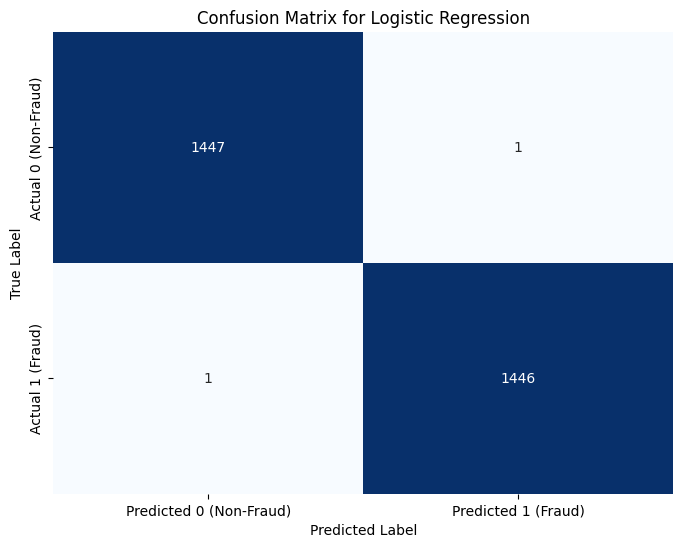

In [82]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Non-Fraud)', 'Predicted 1 (Fraud)'],
            yticklabels=['Actual 0 (Non-Fraud)', 'Actual 1 (Fraud)'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Exploratory Data Analysis

### Multicollinearity Check: Correlation Heatmap

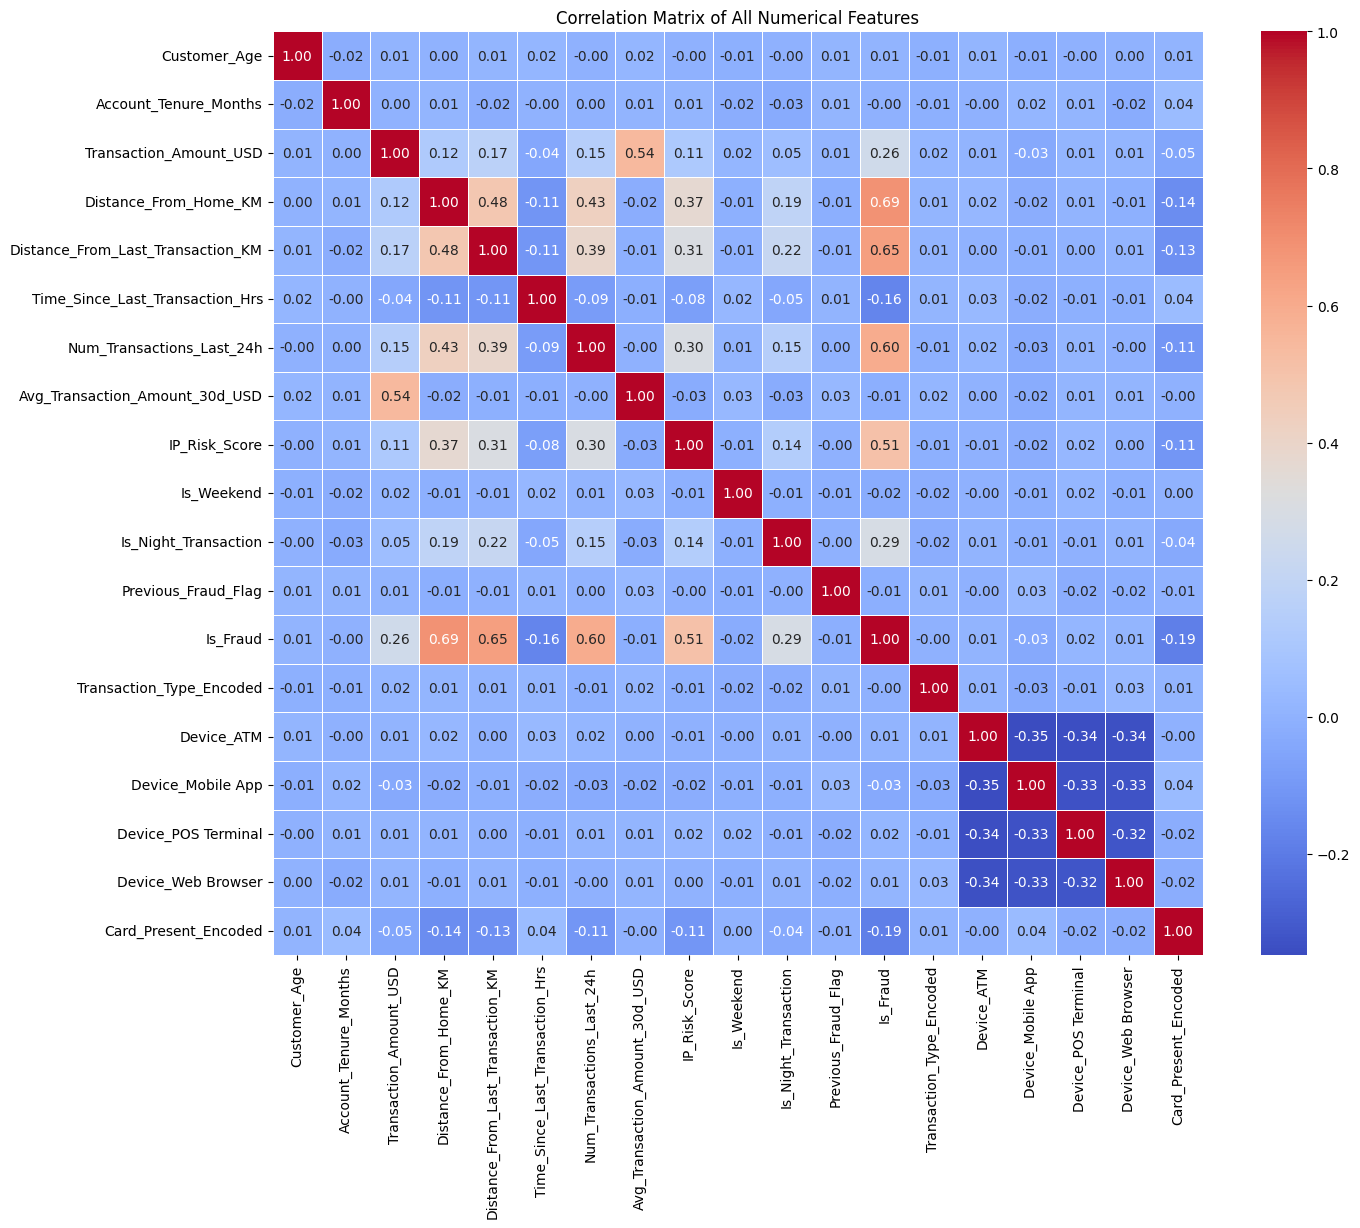

In [75]:
numerical_cols = df.select_dtypes(include=['number']).columns

if numerical_cols.empty:
    print("No numerical columns available to create a correlation heatmap.")
else:
    correlation_matrix = df[numerical_cols].corr()
    plt.figure(figsize=(15, 12)) # Adjusted figure size for more columns
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of All Numerical Features') # Updated title
    plt.show()

##Hyptothesis Testing

### Hypothesis Testing: T-test for 'Is_Fraud' vs. Numerical Features

We will perform independent samples t-tests to compare the means of several numerical features between the two groups defined by the 'Is_Fraud' column (fraudulent vs. non-fraudulent transactions). The null hypothesis ($H_0$) is that there is no significant difference in the mean of the numerical feature between the two groups.

In [76]:
from scipy import stats

# Define the numerical columns to test against 'Is_Fraud'
features_to_test = ['Customer_Age', 'Account_Tenure_Months', 'Transaction_Amount_USD', 'IP_Risk_Score']

# Separate data into fraudulent and non-fraudulent groups
df_fraud = df[df['Is_Fraud'] == 1]
df_non_fraud = df[df['Is_Fraud'] == 0]

print("--- T-test Results ---")
for feature in features_to_test:
    print(f"\nComparing '{feature}' for Fraud vs. Non-Fraud:")

    # Perform independent samples t-test
    t_statistic, p_value = stats.ttest_ind(df_fraud[feature], df_non_fraud[feature], equal_var=False) # Welch's t-test as variances might not be equal

    print(f"  T-statistic: {t_statistic:.3f}")
    print(f"  P-value: {p_value:.3f}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print(f"  Conclusion: Reject the null hypothesis. There is a statistically significant difference in the mean '{feature}' between fraudulent and non-fraudulent transactions.")
    else:
        print(f"  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean '{feature}' between fraudulent and non-fraudulent transactions.")


--- T-test Results ---

Comparing 'Customer_Age' for Fraud vs. Non-Fraud:
  T-statistic: 0.663
  P-value: 0.508
  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean 'Customer_Age' between fraudulent and non-fraudulent transactions.

Comparing 'Account_Tenure_Months' for Fraud vs. Non-Fraud:
  T-statistic: -0.246
  P-value: 0.806
  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean 'Account_Tenure_Months' between fraudulent and non-fraudulent transactions.

Comparing 'Transaction_Amount_USD' for Fraud vs. Non-Fraud:
  T-statistic: 6.390
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in the mean 'Transaction_Amount_USD' between fraudulent and non-fraudulent transactions.

Comparing 'IP_Risk_Score' for Fraud vs. Non-Fraud:
  T-statistic: 36.588
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a st

We Can infer Customer age does not vary with fraudlent transactions .
As the p Value of account tenure is greater than 0.05 we fail to reject null hypothesis  

class work

#Scaling of the data